## Modelo ARIMAX para aplicación de variables exógenas

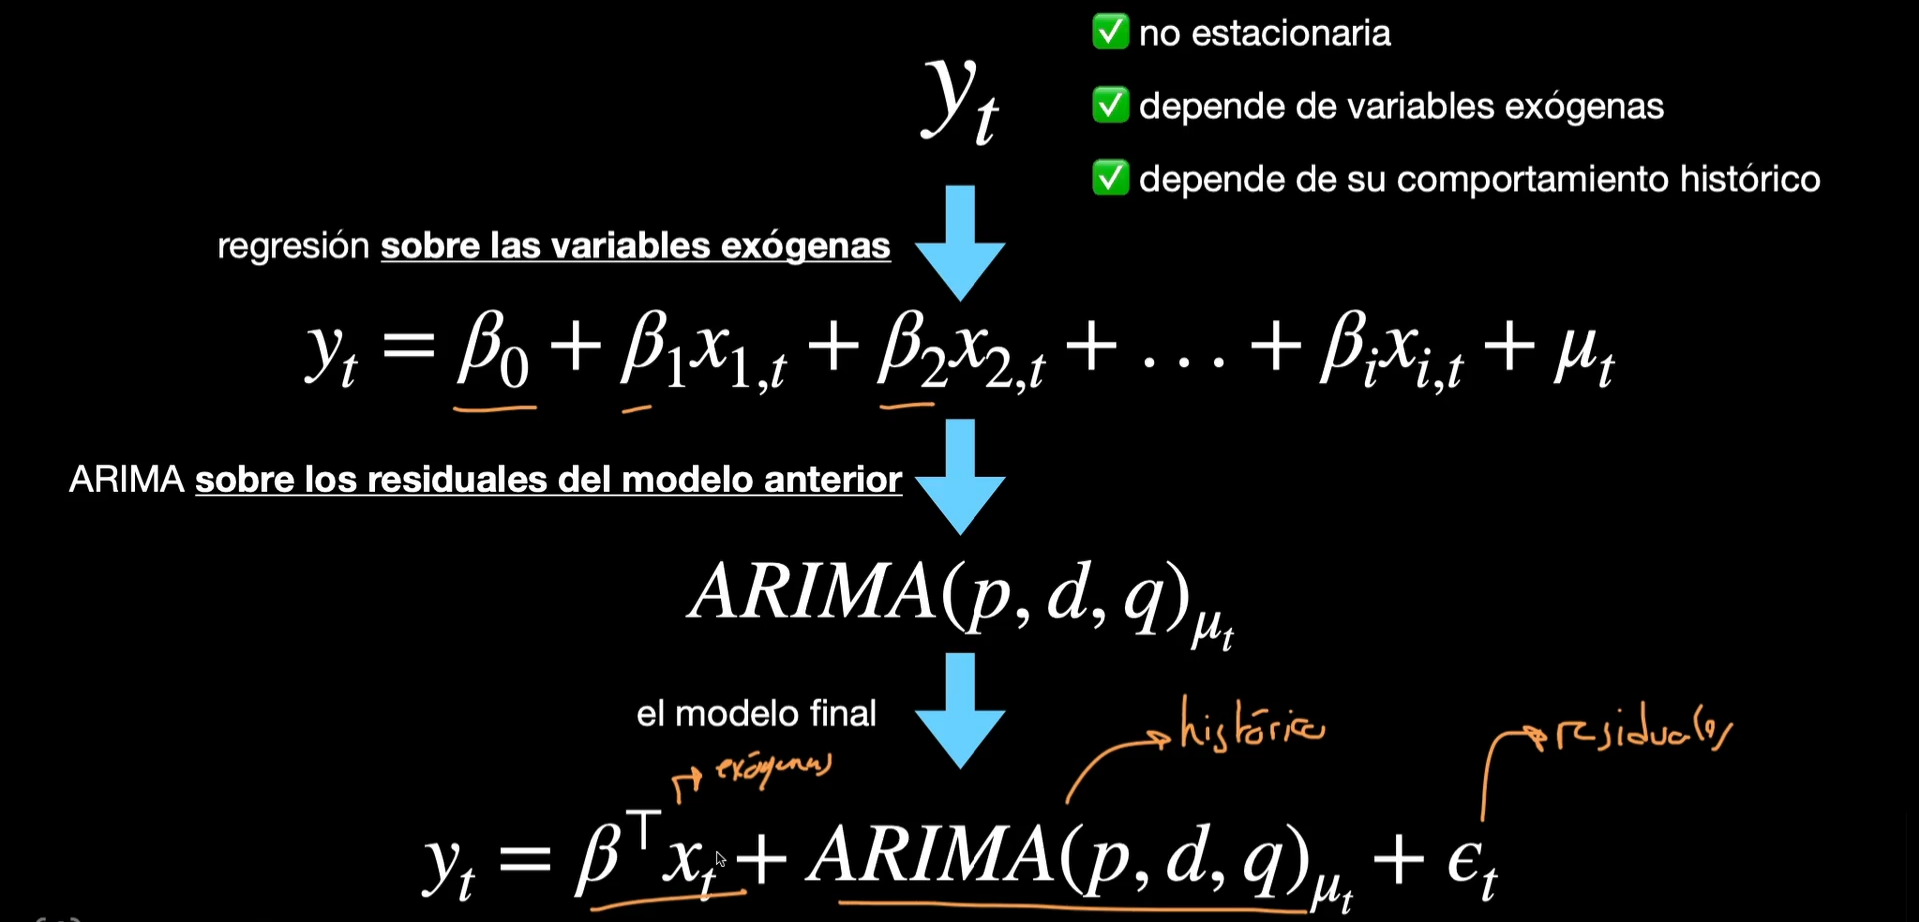

1. Primero se modela un modelo de regresión sobre las variables exógenas.
    - Se capturan las variaciónes mas significativas (**más abruptas**) relacionadas con las variables exógenas
    - NO se alcanza a capturar el comportamiento histórico de la serie
2. Los patrónes que no logra capturar el modelo, son aprendidos entonces por un modelo ARIMA
    - Se construye sobre los residuales del anterior modelo de regresión

In [3]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Modelo de regresión <--------
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast

# Modelo ARIMA con stasforecast
from statsforecast import StatsForecast
from statsforecast.models import ARIMA

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 4)

## El set de datos y el problema a resolver

El set de datos "ventas_arimax.csv" contiene el registro histórico de ventas de una cierta categoría de productos durante el último año.

Además de esto, contamos con datos de dos variables exógenas para el mismo periodo de tiempo:
- Si hubo o no promociones (1 o 0)
- Si se trató de un evento especial o no (1 o 0)

Así que el problema a resolver será:

    > Construir un modelo ARIMAX para pronosticar las ventas con un horizonte de 7 días, que incorpore no sólo el comportamiento histórico de la Serie sino también las variables exógenas

In [4]:
df = pd.read_csv('datos/ventas_arimax.csv', parse_dates=['ds'])
df

,unique_id,ds,promociones,eventos,y
0,productos_C,2025-03-01,0,0,19
1,productos_C,2025-03-02,0,0,18
2,productos_C,2025-03-03,0,0,18
3,productos_C,2025-03-04,0,0,22
4,productos_C,2025-03-05,0,0,19
...,...,...,...,...,...
360,productos_C,2026-02-24,0,0,20
361,productos_C,2026-02-25,0,0,18
362,productos_C,2026-02-26,0,0,21
363,productos_C,2026-02-27,0,1,27


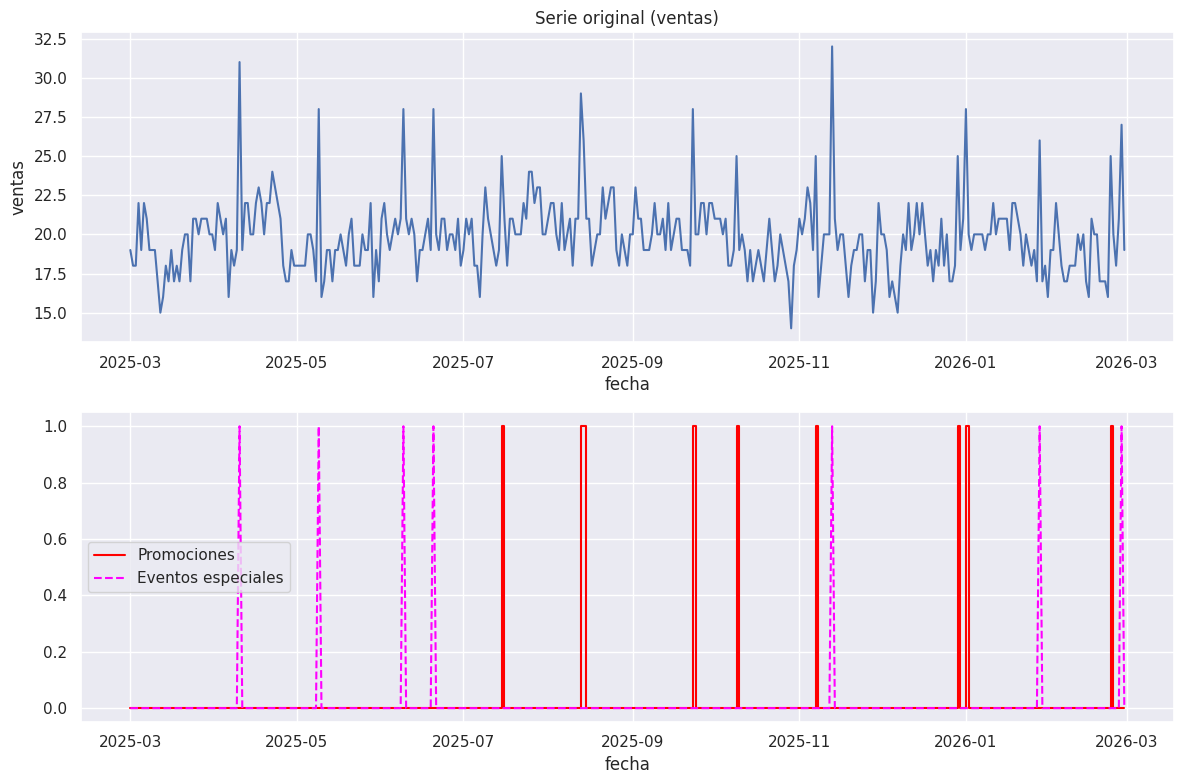

In [5]:
fig, axs = plt.subplots(2,1,figsize=(12,8))

# Serie
sns.lineplot(df, x="ds", y="y", ax=axs[0])
axs[0].set_title('Serie original (ventas)')
axs[0].set_xlabel('fecha')
axs[0].set_ylabel('ventas')

# Variables exógenas
axs[1].plot(df["ds"], df["promociones"], label="Promociones", drawstyle="steps-post", color='red')
axs[1].plot(df["ds"], df["eventos"], label="Eventos especiales", linestyle="--", color='magenta')
axs[1].set_xlabel('fecha')
axs[1].legend()

plt.tight_layout();

## Estimación de los parámetros del modelo ARIMAX

1. Crear el set de entrenamiento y prueba
2. Ajustar un modelo de regresión **sobre las variables exógenas**
3. Calcular los residuales del modelo obtenido en (2)
4. Definir los parámetros del modelo ARIMA que se construirá **sobre los residuales obtenidos en (3)**
5. Habiendo definido los parámetros del modelo ARIMA (4), entrenar y validar el modelo ARIMAX
6. Generar pronósticos con el modelo obtenido en (5)

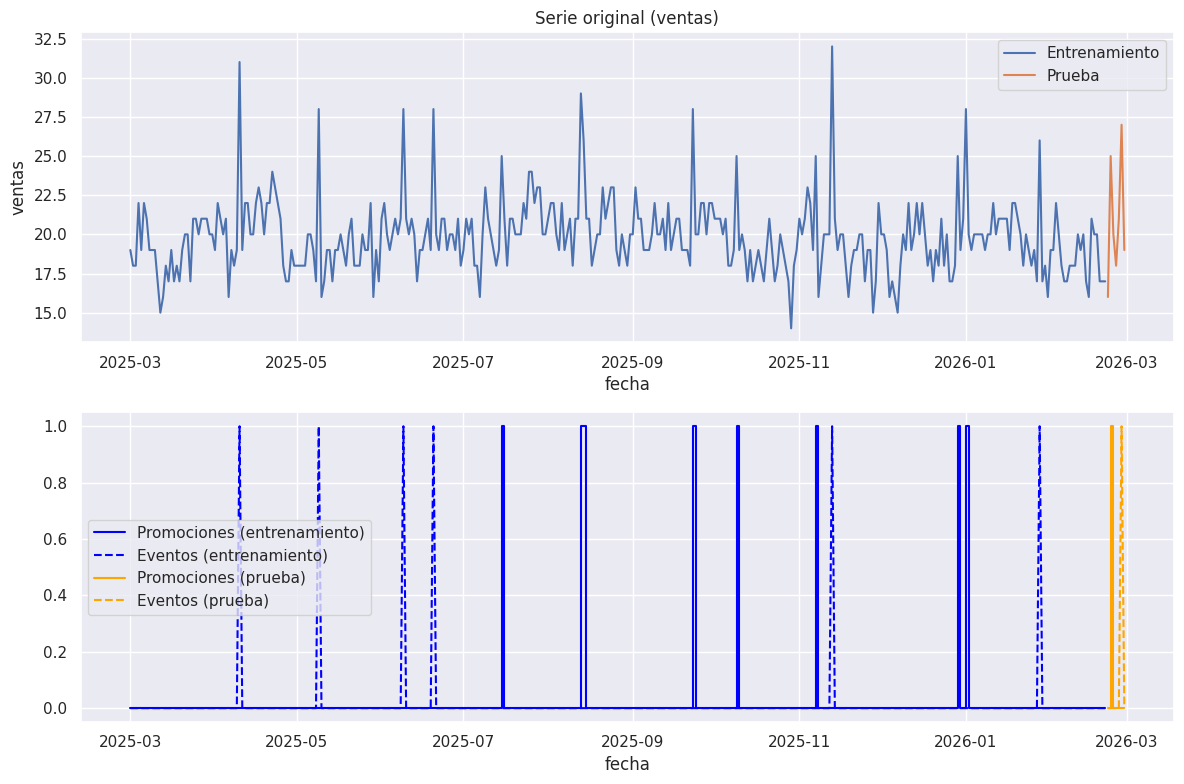

In [7]:
# Entrenamiento y prueba
df_train = df[:-7].copy()
df_test = df[-7:].copy() # Últimos 7 días de prueba

# Graficar
fig, axs = plt.subplots(2,1,figsize=(12,8))

# Serie
sns.lineplot(df_train, x="ds", y="y", ax=axs[0], label='Entrenamiento')
sns.lineplot(df_test, x="ds", y="y", ax=axs[0], label='Prueba')
axs[0].set_title('Serie original (ventas)')
axs[0].set_xlabel('fecha')
axs[0].set_ylabel('ventas')

# Variables exógenas
axs[1].plot(df_train["ds"], df_train["promociones"], label="Promociones (entrenamiento)", color='blue', drawstyle="steps-post")
axs[1].plot(df_train["ds"], df_train["eventos"], label="Eventos (entrenamiento)", color='blue', linestyle='--')

axs[1].plot(df_test["ds"], df_test["promociones"], label="Promociones (prueba)", color='orange', drawstyle="steps-post")
axs[1].plot(df_test["ds"], df_test["eventos"], label="Eventos (prueba)", color='orange', linestyle='--')

axs[1].set_xlabel('fecha')
axs[1].legend()

plt.tight_layout()

### Modelo de regresión sobre las variables exógenas

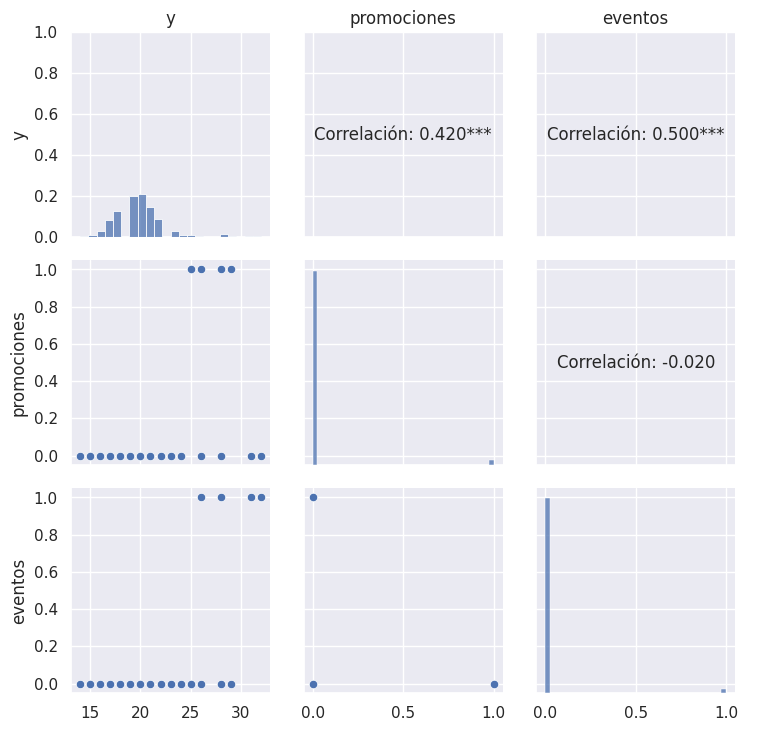

In [8]:
def correlacion(x, y, **kws):
    # Calcular índice de correlación y valor p
    r, p = pearsonr(x, y)
    
    ax = plt.gca()
    ax.annotate(f"Correlación: {r:.3f}{'***' if p < 0.05 else ''}",
                xy=(0.5, 0.5),
                xycoords = "axes fraction",
                ha = "center",
                va = "center",
    )
    
df_plot = df_train[["y", "promociones", "eventos"]].copy()

# Gráfico tipo Pairgrid: debajo de la diagonal -> gráficos de dispersión,
#                        encima de la diagonal -> Niveles de correlación
pg = sns.PairGrid(df_plot)
pg.map_diag(sns.histplot)
pg.map_upper(correlacion)
pg.map_lower(sns.scatterplot)
pg.add_legend()

pg.set(xlabel="")

for i, col in enumerate(df_plot.columns):
    pg.axes[0,i].set_title(col)

In [9]:
mlf = MLForecast(models=[LinearRegression()], freq = 'd')

mlf.fit(df = df_train, fitted = True)
# Para que genere predicciones in-sample, porque lo que me interesa son los residuales después de entrenar con las variables exógenas
# No me interesan pronósticos a futuro, me interesa generar pronostícos sobre los mismo datos historicos de entrenamiento

# Predicciones in-sample
preds_is = mlf.forecast_fitted_values()
preds_is

,unique_id,ds,y,LinearRegression
0,productos_C,2025-03-01,19.0,19.526163
1,productos_C,2025-03-02,18.0,19.526163
2,productos_C,2025-03-03,18.0,19.526163
3,productos_C,2025-03-04,22.0,19.526163
4,productos_C,2025-03-05,19.0,19.526163
...,...,...,...,...
353,productos_C,2026-02-17,20.0,19.526163
354,productos_C,2026-02-18,20.0,19.526163
355,productos_C,2026-02-19,17.0,19.526163
356,productos_C,2026-02-20,17.0,19.526163


<Axes: xlabel='ds', ylabel='y'>

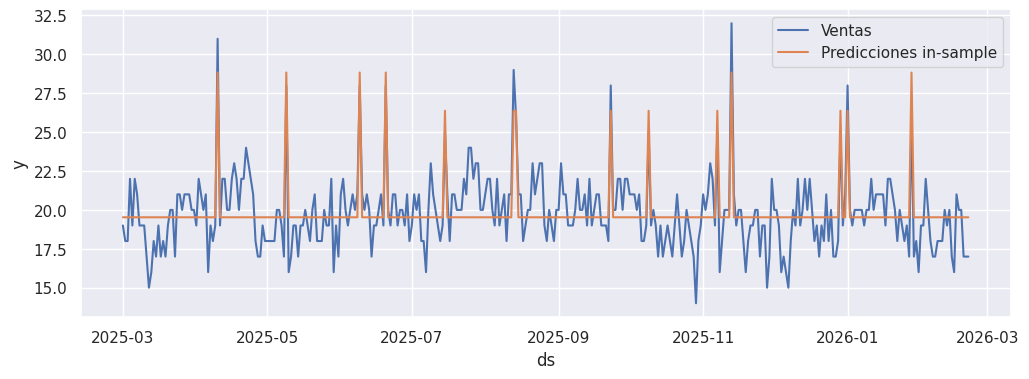

In [10]:
# Gráfico y vs. regresión variables exógenas
sns.lineplot(preds_is, x="ds", y="y", label='Ventas')
sns.lineplot(preds_is, x="ds", y="LinearRegression", label='Predicciones in-sample')

Se puede ver que la regresión lineal sobre las variables exógenas puede modelar las variaciones **más abruptas** de la serie de tiempo original, pero para el resto de la estructura temporal es donde se va a implementar un ARIMA recibiedolos como residuales, que es lo que no captura el modelo lineal.

### Residuales del modelo de regresión

<Axes: >

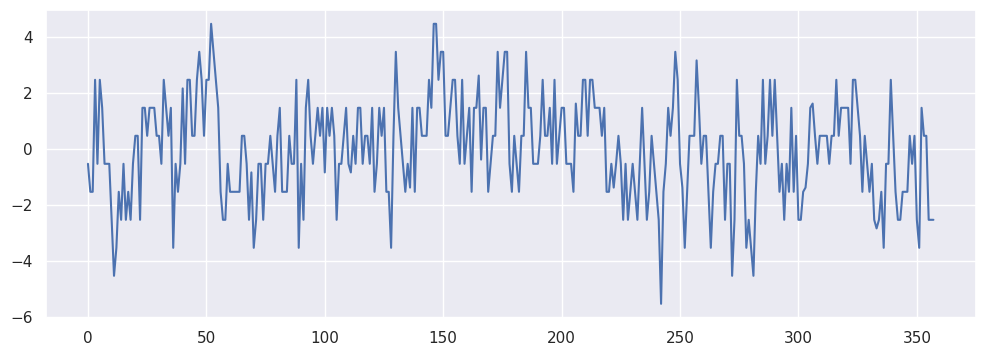

In [11]:
res = preds_is["y"] - preds_is["LinearRegression"]
sns.lineplot(res)

In [12]:
def prueba_diferenciacion(serie, d, titulo):

    serie = serie.dropna()
    if d != 0:
        for _ in range(d):
            serie = serie.diff()

    resultado = adfuller(serie.dropna())
    pval = resultado[1]
    
    if pval < 0.05:
        print(f'La serie es estacionaria porque p = {pval:.2f} < 0.05. NO se requiere diferenciación')
    else:
        print(f'La serie NO es estacionaria porque p = {pval:.2f} >= 0.05. Se requiere diferenciación')
        
    fig, ax = plt.subplots(1,1,figsize=(12,4))
    plt.plot(range(1,len(serie)+1), serie)
    plt.hlines(serie.mean(), xmin=1, xmax=len(serie)+1, color='red', linestyle='--')
    ax.set_title(titulo)

La serie es estacionaria porque p = 0.00 < 0.05. NO se requiere diferenciación
La serie es estacionaria porque p = 0.00 < 0.05. NO se requiere diferenciación


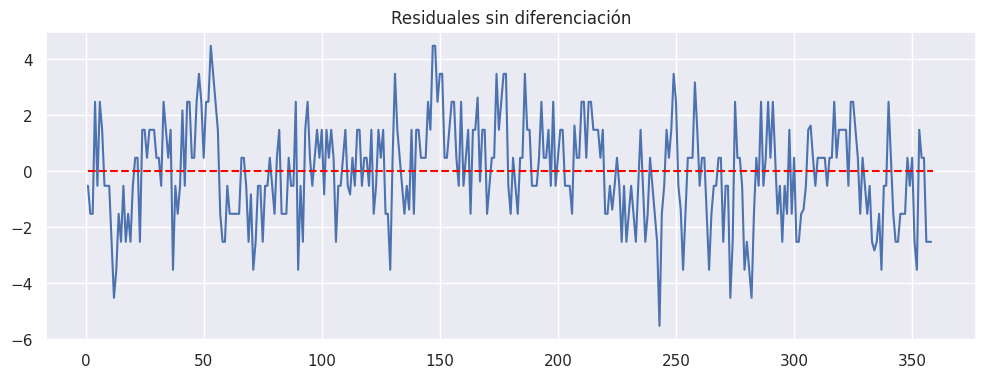

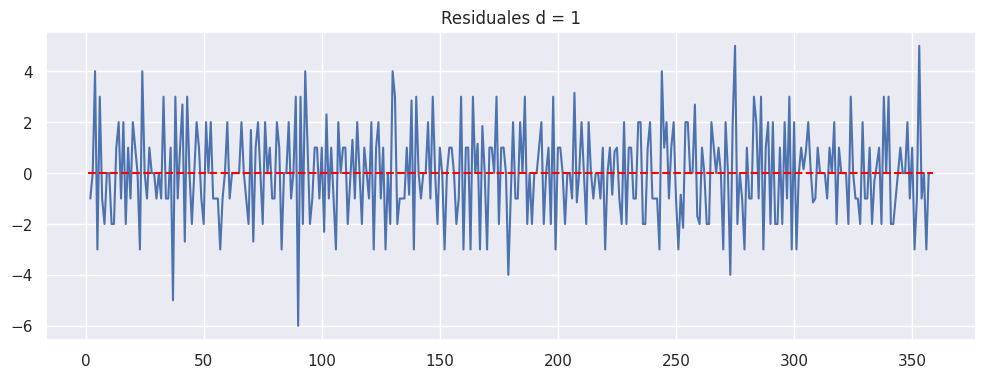

In [14]:
prueba_diferenciacion(res, d=0, titulo='Residuales sin diferenciación')
prueba_diferenciacion(res, d=1, titulo='Residuales d = 1')